# Task 3: Perturbation Prediction
Can a model predict transcriptome changes for a gene that was not knocked out in the training data?

Before model training, **select a subset of 50 perturbations for modeling** and explain your choice. Of these, **select a subset of perturbations that are held out**, i.e., not used during training or hyperparameter selection, only at test time. If the number of selected genes is still too high for the model you want to train, you may subset it further and explain your choice. You may also use unperturbed cells.

**The target variable to predict by your models is the mean log2 fold change per condition and perturbation target**. Train two (if one student), **three (if two students)** or four (if three students) types of models. Here, a type of model is a feature engineering strategy combined with a learning algorithm. At least one of the models should be deliberately simplistic. Evaluate the model performance and uncertainty based on suitable metrics and interpret the results biologically.
You may also use the protein data, however, this is not required. Students working alone only need to use data from the co-culture condition.

## 0.Setup

In [1]:
# !pip install decoupler

In [2]:
# !pip install pertpy

In [3]:
# !pip install pydeseq2

In [4]:
import numpy as np
import anndata as ad
import scanpy as sc
import matplotlib.pyplot as plt
import pandas as pd

import decoupler as dc
# import lamindb as ln
import pertpy as pt

/home/ubuntu/miniconda3/envs/denbi/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
# INPUT_FILE = '/home/ubuntu/data/frangieh/rna.qc.clust.h5ad' # HVG 5000
INPUT_FILE ='/home/ubuntu/data/frangieh/rna.strictqc.hvg100.h5ad'
# INPUT_FILE ='/home/ubuntu/data/frangieh/rna.qc.hvg200.h5ad'
PROTEIN_FILE ='/home/ubuntu/data/frangieh/protein.h5ad'
sc.settings.verbosity = 1
RANDOM_STATE = 1

In [6]:
adata = ad.read_h5ad(INPUT_FILE)

In [7]:
adata

AnnData object with n_obs × n_vars = 118109 × 22097
    obs: 'library_preparation_protocol', 'perturbation_2', 'MOI', 'sgRNA', 'UMI_count', 'guide_id', 'perturbation', 'tissue_type', 'cancer', 'disease', 'perturbation_type', 'celltype', 'organism', 'perturbation_type_2', 'nperts', 'ngenes', 'ncounts', 'percent_mito', 'percent_ribo', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'outlier'
    var: 'ensembl_id', 'ncounts', 'ncells', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispers

In [8]:
adata.obs

,library_preparation_protocol,perturbation_2,MOI,sgRNA,UMI_count,guide_id,perturbation,tissue_type,cancer,disease,...,log1p_total_counts_mt,pct_counts_mt,total_counts_ribo,log1p_total_counts_ribo,pct_counts_ribo,total_counts_hb,log1p_total_counts_hb,pct_counts_hb,n_genes,outlier
cell_name,,,,,,,,,,,,,,,,,,,,,
CELL_2,10X 3' v3 sequencing,Control,2,nan,10731.0,NGFR_3;SERPINF1_3,NGFR,cell_line_co-culture,True,melanoma,...,6.259582,4.864411,1363.0,7.218177,12.701519,0.0,0.000000,0.000000,3531,False
CELL_4,10X 3' v3 sequencing,Control,2,nan,15322.0,NMRK1_3;S100A6_3,NMRK1,cell_line_co-culture,True,melanoma,...,6.781058,5.743375,2340.0,7.758334,15.272159,1.0,0.693147,0.006527,4086,False
CELL_5,10X 3' v3 sequencing,Control,0,nan,10314.0,nan,control,cell_line_co-culture,True,melanoma,...,6.342122,5.497382,1558.0,7.351800,15.105681,0.0,0.000000,0.000000,3178,False
CELL_6,10X 3' v3 sequencing,Control,1,IFNGR1_1,8810.0,IFNGR1_1,IFNGR1,cell_line_co-culture,True,melanoma,...,6.522093,7.707151,1002.0,6.910751,11.373440,0.0,0.000000,0.000000,3124,False
CELL_8,10X 3' v3 sequencing,Control,1,CDKN1A_3,8491.0,CDKN1A_3,CDKN1A,cell_line_co-culture,True,melanoma,...,6.082219,5.146626,774.0,6.652863,9.115534,0.0,0.000000,0.000000,3157,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CELL_218326,10X 3' v3 sequencing,Co-culture,1,AHNAK_2,16010.0,AHNAK_2,AHNAK,cell_line_co-culture,True,melanoma,...,7.198931,8.351031,2087.0,7.643962,13.035603,1.0,0.693147,0.006246,4151,False
CELL_218327,10X 3' v3 sequencing,Co-culture,4,nan,12722.0,CTSO_3;PIK3IP1_3;VDAC2_2;WNT7A_1,CTSO,cell_line_co-culture,True,melanoma,...,6.391917,4.684798,1701.0,7.439559,13.370540,0.0,0.000000,0.000000,3686,False
CELL_218328,10X 3' v3 sequencing,Co-culture,2,nan,11643.0,JAK2_3;SLC7A5P1_3,JAK2,cell_line_co-culture,True,melanoma,...,6.230482,4.354548,1630.0,7.396949,13.999828,2.0,1.098612,0.017178,3462,False


In [9]:
# adata.var.loc[adata.var['highly_variable'] == True, ['means', 'dispersions', 'dispersions_norm']].sort_values('dispersions_norm',
#                                                                                           ascending=False)

In [10]:
adata.obs['perturbation_2'].value_counts()

perturbation_2
IFNγ          52307
Co-culture    33008
Control       32794
Name: count, dtype: int64

In [11]:
adata.obs['perturbation'].value_counts()

perturbation
control    29491
ACTA2        767
B2M          725
AEBP1        704
A2M          695
           ...  
RACK1         21
UBA52         21
PSMA7         13
UBL5          11
TUBB           9
Name: count, Length: 249, dtype: int64

In [12]:
# protein = ad.read_h5ad(PROTEIN_FILE)
# protein

## 1.Data prep

In [13]:
# Justification for perturbation choice
#
#  TEXT HERE!
#
# perturbations = adata.obs['perturbation'].value_counts()
# print(perturbations)
pert_genes = ['MYC', 'B2M', 'JAK1', 'JAK2', 'IFNGR1', 'IFNGR2'] # Test selection
pert_adata = adata[adata.obs['perturbation'].isin(['control']+pert_genes)].copy()
pert_adata = pert_adata[:, pert_genes].copy()
print(pert_adata)

AnnData object with n_obs × n_vars = 32418 × 6
    obs: 'library_preparation_protocol', 'perturbation_2', 'MOI', 'sgRNA', 'UMI_count', 'guide_id', 'perturbation', 'tissue_type', 'cancer', 'disease', 'perturbation_type', 'celltype', 'organism', 'perturbation_type_2', 'nperts', 'ngenes', 'ncounts', 'percent_mito', 'percent_ribo', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'outlier'
    var: 'ensembl_id', 'ncounts', 'ncells', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_

### 1.1 Target label

_The target variable to predict by your models is the mean log2 fold change per condition and perturbation target._

/home/ubuntu/miniconda3/envs/denbi/lib/python3.13/site-packages/scanpy/plotting/_utils.py:509: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


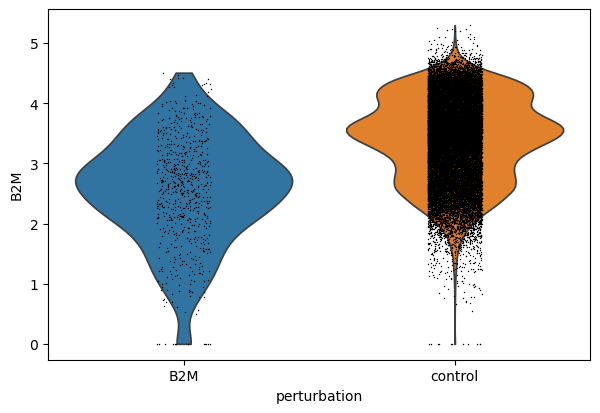

In [14]:
# for gene in pert_genes:
#     sc.pl.violin(adata[adata.obs['perturbation'].isin([gene, 'control'])], keys=gene, groupby='perturbation')
sc.pl.violin(adata[adata.obs['perturbation'].isin(['B2M', 'control'])], keys='B2M', groupby='perturbation')

In [15]:
pert_adata.obs["sample"] = pd.Categorical(
    f"{rep}_{l}" for rep, l in zip(
        pert_adata.obs["perturbation"],
        pert_adata.obs["perturbation_2"],
        strict=False
    )
)
pert_adata.obs["sample"].value_counts()

sample
control_IFNγ          13437
control_Control        8057
control_Co-culture     7997
B2M_IFNγ                310
IFNGR2_IFNγ             241
B2M_Co-culture          222
IFNGR2_Co-culture       214
JAK1_IFNγ               209
JAK2_Co-culture         205
JAK2_IFNγ               195
B2M_Control             193
IFNGR1_IFNγ             183
JAK1_Co-culture         160
IFNGR1_Co-culture       150
JAK2_Control            145
IFNGR2_Control          136
IFNGR1_Control          131
JAK1_Control            121
MYC_IFNγ                 43
MYC_Co-culture           39
MYC_Control              30
Name: count, dtype: int64

In [16]:
# pert_pb = dc.pp.pseudobulk(
#     pert_adata, sample_col="sample",
#     groups_col=None, #'perturbation_2',
#     layer="counts",
#     mode="sum"
# )
# print(pert_pb)
# pert_pb.obs

In [17]:
# dc.pl.filter_samples(
#     adata=pert_pb,
#     groupby=["perturbation_2", "perturbation"],
#     min_cells=10,
#     min_counts=1000,
#     figsize=(5, 8),
# )

In [18]:
# dc.pp.filter_samples(pert_pb, min_cells=10,min_counts=1000)

In [19]:
# dc.pl.obsbar(adata=pert_pb, y="sample", hue="perturbation_2", figsize=(6, 3))

In [20]:
mono_pert_ad = pert_adata[pert_adata.obs['perturbation'] == 'B2M'].copy()
mono_pert_ad.layers['norm'] = mono_pert_ad.X
mono_pert_ad.X = mono_pert_ad.layers['counts']
mono_pert_ad

AnnData object with n_obs × n_vars = 725 × 6
    obs: 'library_preparation_protocol', 'perturbation_2', 'MOI', 'sgRNA', 'UMI_count', 'guide_id', 'perturbation', 'tissue_type', 'cancer', 'disease', 'perturbation_type', 'celltype', 'organism', 'perturbation_type_2', 'nperts', 'ngenes', 'ncounts', 'percent_mito', 'percent_ribo', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'outlier', 'sample'
    var: 'ensembl_id', 'ncounts', 'ncells', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'disp

In [21]:
# dc.pl.filter_by_expr(
#     adata=mono_pert_pb,
#     group="perturbation_2",
#     min_count=10,
#     min_total_count=15,
#     large_n=10,
#     min_prop=0.7,
# )
# dc.pl.filter_by_prop(
#     adata=mono_pert_pb,
#     min_prop=0.1,
#     min_smpls=2,
# )

In [22]:
pds2 = pt.tl.PyDESeq2(adata=mono_pert_ad,design='~ perturbation_2')

In [23]:
pds2

In [26]:
pds2.fit()

Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
/home/ubuntu/miniconda3/envs/denbi/lib/python3.13/site-packages/pydeseq2/dds.py:539: UserWarning: Every gene contains at least one zero, cannot compute log geometric means. Switching to iterative mode.
  self.fit_size_factors(
Fitting dispersions...
... done in 0.03 seconds.

Fitting MAP dispersions...
... done in 0.02 seconds.

Fitting dispersions...
... done in 2.94 seconds.

Fitting MAP dispersions...
... done in 3.22 seconds.

Fitting dispersions...
... done in 2.82 seconds.

Fitting MAP dispersions...
... done in 2.60 seconds.

Fitting dispersions...
... done in 2.89 seconds.

Fitting MAP dispersions...
... done in 2.86 seconds.

Fitting dispersions...
... done in 2.56 seconds.

Fitting MAP dispersions...
... done in 2.97 seconds.

Fitting dispersions...
... done in 2.71 seconds.

Fitting MAP dispersions...
... done in 2.46 seconds.

Fitting dispersions...
... done in 2.65 seconds.

Fitting MAP dispersions...
... done in 2.93 seconds.

Fitting dispersions..

In [27]:
res_df = pds2.test_contrasts(pds2.contrast(
    column="perturbation_2",
    baseline="Control",
    group_to_compare="Co-culture")
)

Log2 fold change & Wald test p-value, contrast vector: [ 0. -1.  0.]
                 baseMean  log2FoldChange     lfcSE       stat         pvalue  \
gene_symbol                                                                     
MYC              0.370351        0.203629  0.171803   1.185252   2.359177e-01   
B2M          21430.753020       12.314393  0.412148  29.878569  3.736602e-196   
JAK1             0.389483       -0.266706  0.140176  -1.902646   5.708676e-02   
JAK2            17.216136        0.230749  1.125700   0.204982   8.375858e-01   
IFNGR1           0.292360        0.464829  0.144771   3.210791   1.323703e-03   
IFNGR2           0.401194       -0.037897  0.122670  -0.308934   7.573720e-01   

                      padj  
gene_symbol                 
MYC           3.538765e-01  
B2M          2.241961e-195  
JAK1          1.141735e-01  
JAK2          8.375858e-01  
IFNGR1        3.971109e-03  
IFNGR2        8.375858e-01  


Running Wald tests...
... done in 0.01 seconds.



In [31]:
res_df.to_csv('/home/ubuntu/data/frangieh/b2m-control-coculture-dge.csv')